<a href="https://colab.research.google.com/github/satyaa2429/Satya/blob/main/Copy_of_Untitled0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Reasoning**:
The error `ValueError: num must be an integer with 1 <= num <= 33, not 34` indicates that the subplot index is exceeding the calculated grid size. This is likely due to an incorrect calculation of the number of columns in the subplot grid or the total number of plots. Recalculate the subplot layout to ensure the index is within the valid range and continue displaying images from the remaining classes and splits.

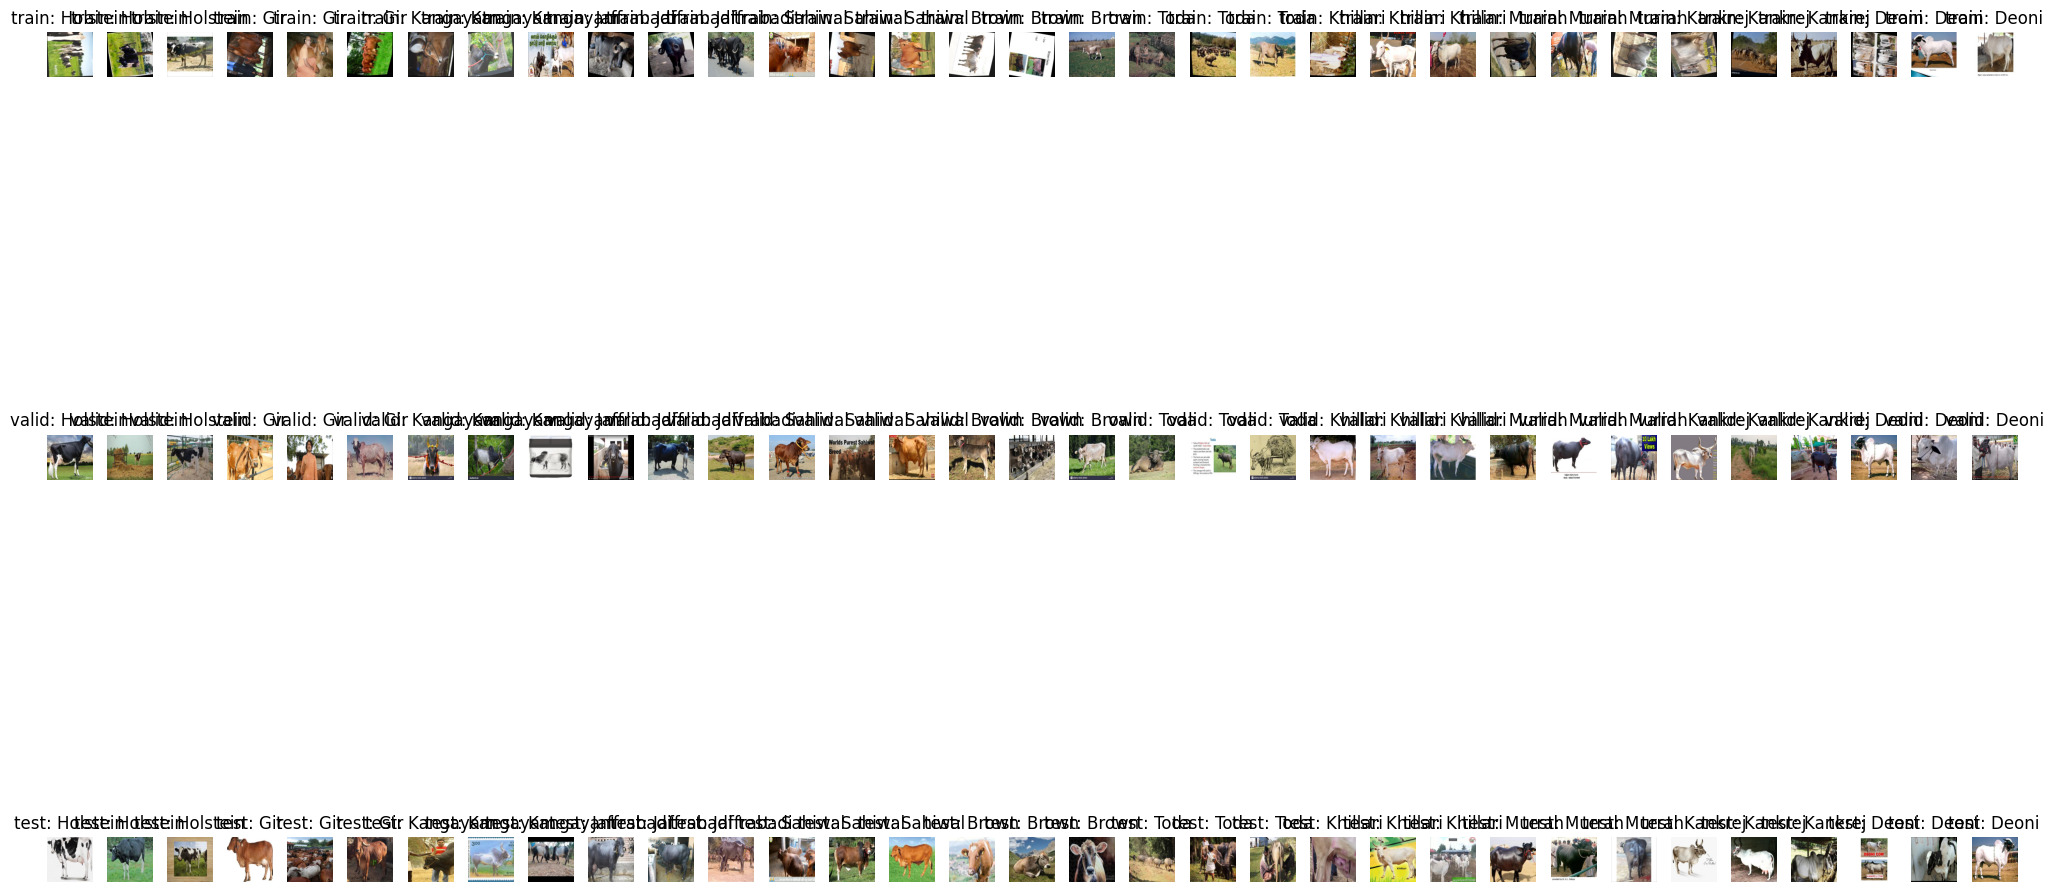

In [ ]:
# Reset the plot index and figure to create a new set of subplots
plt.close('all') # Close previous figures
plt.figure(figsize=(20, 15)) # Increase figure size for better visualization
plot_index = 1

# Recalculate the number of columns needed. We want to show num_images_to_display per class.
# Total classes to display = number of known classes
# Total images to display per split = len(known_classes) * num_images_to_display
# Since we are plotting all splits in one figure, we can arrange them in rows of splits and columns of classes*images_per_class
n_cols = len(known_classes) * num_images_to_display
n_rows = len(data_splits)

for split in data_splits:
    split_dir = os.path.join(extract_dir, split)
    if os.path.exists(split_dir):
        files = os.listdir(split_dir)
        sample_images = {class_name: [] for class_name in known_classes}

        for file_name in files:
            if os.path.isfile(os.path.join(split_dir, file_name)) and file_name.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
                class_name = "unknown"
                for known_class in known_classes:
                    if file_name.lower().startswith(known_class.lower()):
                        class_name = known_class
                        break

                if class_name in sample_images and len(sample_images[class_name]) < num_images_to_display:
                    sample_images[class_name].append(os.path.join(split_dir, file_name))

        # Display the collected sample images for this split
        for class_name in known_classes: # Iterate through known classes to maintain order
            image_paths = sample_images.get(class_name, []) # Get images for the class, default to empty list if none found
            for img_path in image_paths:
                # Calculate subplot position: row is based on split index, column is based on class index and image index within class
                split_index = data_splits.index(split)
                class_index = known_classes.index(class_name)
                image_index = image_paths.index(img_path)
                subplot_num = split_index * n_cols + class_index * num_images_to_display + image_index + 1

                if subplot_num <= n_rows * n_cols: # Ensure subplot number is within the grid
                    plt.subplot(n_rows, n_cols, subplot_num)
                    try:
                        img = Image.open(img_path)
                        plt.imshow(img)
                        plt.title(f"{split}: {class_name}")
                        plt.axis('off')
                    except Exception as e:
                        print(f"Could not open or display image {img_path}: {e}")

plt.tight_layout()
plt.show()

## Visualize training history

### Subtask:
Plot the accuracy and loss curves from the training history to understand the model's learning process.

**Reasoning**:
Plot the training and validation accuracy and loss curves from the history object to visualize the model's performance during training.

In [ ]:
import matplotlib.pyplot as plt

# Extract accuracy and loss from history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(epochs)

# Plot accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.show()

**Reasoning**:
Continue displaying sample images from the remaining classes in the train split and then proceed to the valid and test splits.

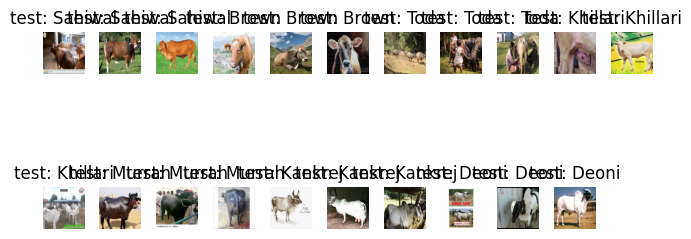

In [ ]:
# Continue displaying images for the remaining classes in the 'train' split
for class_name, image_paths in sample_images.items():
    if class_name in ['Sahiwal', 'Brown', 'Toda', 'Khillari', 'Murrah', 'Kankrej', 'Deoni']:
        for img_path in image_paths:
            if plot_index <= 30: # Increase the limit to accommodate more plots
                plt.subplot(len(data_splits), len(known_classes) * num_images_to_display // len(data_splits), plot_index)
                try:
                    img = Image.open(img_path)
                    plt.imshow(img)
                    plt.title(f"{split}: {class_name}")
                    plt.axis('off')
                    plot_index += 1
                except Exception as e:
                    print(f"Could not open or display image {img_path}: {e}")

plt.tight_layout()
plt.show()

**Reasoning**:
Define the base directory and iterate through splits and classes to find and display sample images.

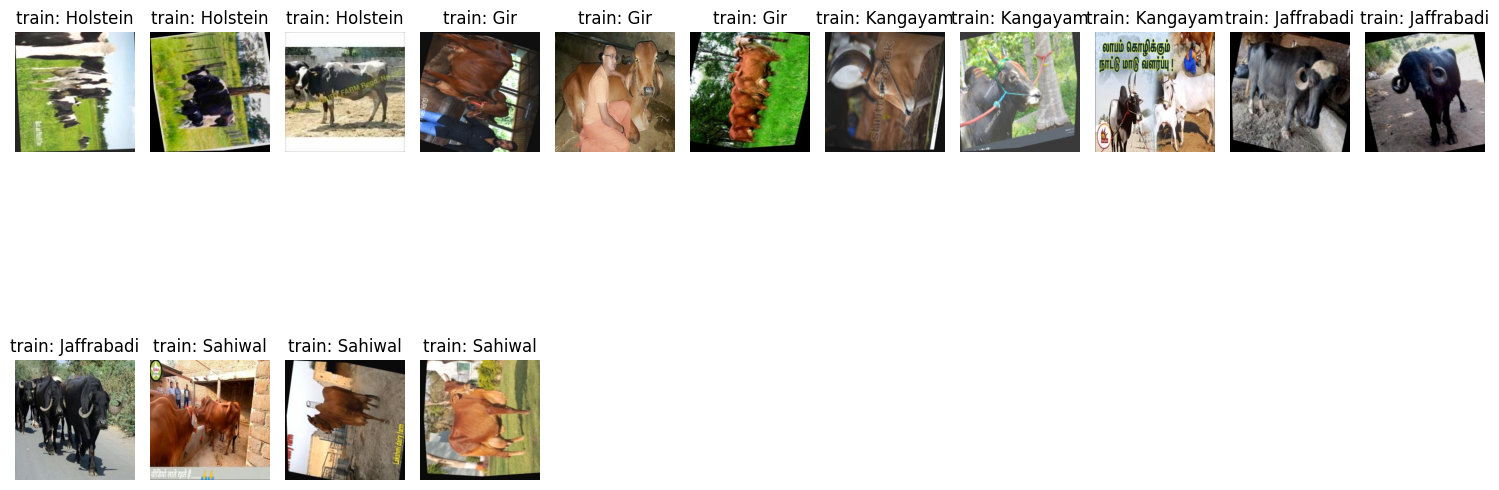

In [ ]:
extract_dir = '/content/cattle-buffalo-breeds'
data_splits = ['train', 'valid', 'test']
known_classes = ['Holstein', 'Gir', 'Kangayam', 'Jaffrabadi', 'Sahiwal', 'Brown', 'Toda', 'Khillari', 'Murrah', 'Kankrej', 'Deoni'] # Use the known classes identified earlier

num_images_to_display = 3

plt.figure(figsize=(15, 10))
plot_index = 1

for split in data_splits:
    split_dir = os.path.join(extract_dir, split)
    if os.path.exists(split_dir):
        files = os.listdir(split_dir)
        # Create a dictionary to store a few image paths for each known class in this split
        sample_images = {class_name: [] for class_name in known_classes}

        for file_name in files:
            if os.path.isfile(os.path.join(split_dir, file_name)) and file_name.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
                class_name = "unknown"
                # Try to find a known class name at the beginning of the filename
                for known_class in known_classes:
                    if file_name.lower().startswith(known_class.lower()):
                        class_name = known_class
                        break

                if class_name in sample_images and len(sample_images[class_name]) < num_images_to_display:
                    sample_images[class_name].append(os.path.join(split_dir, file_name))

        # Display the collected sample images
        for class_name, image_paths in sample_images.items():
            for img_path in image_paths:
                if plot_index <= 15: # Limit the total number of plots to avoid overcrowding
                    plt.subplot(len(data_splits), len(known_classes) * num_images_to_display // len(data_splits), plot_index)
                    try:
                        img = Image.open(img_path)
                        plt.imshow(img)
                        plt.title(f"{split}: {class_name}")
                        plt.axis('off')
                        plot_index += 1
                    except Exception as e:
                        print(f"Could not open or display image {img_path}: {e}")
                        # Optionally skip or show a placeholder

plt.tight_layout()
plt.show()

## Visualize sample images

### Subtask:
Display a few images from each class to understand the data visually.

**Reasoning**:
Import the necessary libraries for image handling and plotting.

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import os

**Reasoning**:
The previous output shows that the heuristic for extracting class names from filenames was not entirely accurate, resulting in many entries with a count of 3 and various fragmented class names. I need a more robust way to determine the correct class name from the filename. Based on the filename pattern like 'ClassName_Number_jpg.rf.randomstring.jpg', I will refine the class name extraction to look for known class names at the beginning of the string or try splitting by `_` and taking the first part, while also handling the `.rf.` part. I will iterate through the files again with an improved parsing logic.

In [ ]:
import os

extract_dir = '/content/cattle-buffalo-breeds'

# Define a list of known class names to help with parsing
known_classes = ['Holstein', 'Gir', 'Kangayam', 'Jaffrabadi', 'Sahiwal', 'Brown', 'Toda', 'Khillari', 'Murrah', 'Kankrej', 'Deoni']

# Count images per class in train, valid, and test directories with improved filename parsing
data_splits = ['train', 'valid', 'test']
class_counts = {}

print("Counting images per class in train, valid, and test directories with improved parsing:")
for split in data_splits:
    split_dir = os.path.join(extract_dir, split)
    class_counts[split] = {}
    if os.path.exists(split_dir):
        print(f"\nProcessing {split} directory:")
        files = os.listdir(split_dir)
        for file_name in files:
            if os.path.isfile(os.path.join(split_dir, file_name)) and file_name.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
                class_name = "unknown" # Default
                # Try to find a known class name at the beginning of the filename
                for known_class in known_classes:
                    if file_name.lower().startswith(known_class.lower()):
                        class_name = known_class
                        break

                # If not found, try splitting by '_' and then removing the .rf. part
                if class_name == "unknown":
                    parts = file_name.split('_')
                    if parts:
                         potential_class_name = parts[0]
                         if '.rf.' in potential_class_name:
                              potential_class_name = potential_class_name.split('.rf.')[0]
                         # Basic check to see if the potential class name looks reasonable (e.g., not a hash or very short)
                         if len(potential_class_name) > 2: # Arbitrary threshold
                              class_name = potential_class_name


                if class_name not in class_counts[split]:
                    class_counts[split][class_name] = 0
                class_counts[split][class_name] += 1
    else:
        print(f"  Directory not found: {split_dir}")

print("\nSummary of image counts per class:")
for split, counts in class_counts.items():
    print(f"{split}:")
    if counts:
        # Sort classes alphabetically for consistent output
        for class_name in sorted(counts.keys()):
            print(f"  {class_name}: {counts[class_name]}")
    else:
        print(f"  No images found or processed in {split}")

Counting images per class in train, valid, and test directories with improved parsing:

Processing train directory:

Processing valid directory:

Processing test directory:

Summary of image counts per class:
train:
  0bf82152-ae93-4462-bafb-eee8d1ebd8a4: 3
  0c28ac923a30fb7dae2036df04c54b46: 3
  0e6146483fc564a89c39993ff0447d42-dairy-cattle-leche: 3
  112937886: 3
  113b7c839cfe05bc8f12bfa9f15b4b2b: 3
  15505982328: 3
  15510987120: 3
  21316b7e270e541b900fe77c70550e29-leche-cattle: 3
  307fec7089e88b6a62d6b9a02dabda34: 3
  355808778: 3
  35cece704258d0abc21fa401a1a2760b-cows-and-calves-longhorns: 3
  3Untitled: 3
  3b473e576eca4a8c7ee4023b43f8a7ac: 3
  464422-lead1: 3
  50301-scaled: 3
  53887fb697bbf0847d8a59f95e157477: 3
  68cc08b76085f66aec24d1b5f72008ea: 3
  71670082: 3
  7720855022: 3
  9c83e3d8f675e5fd6e9559f69982bcc3-cattle-calves: 3
  Brown: 456
  Cow: 3
  Deoni: 180
  Gir: 621
  Gyr-Cattle-Picture: 3
  Gyr-cow-min-1024x683: 3
  High-Milk-Gir-Cow: 3
  Holstein: 645
  IMG: 3
 

**Reasoning**:
The output of listing the 'train' directory shows that the images are directly within the 'train', 'valid', and 'test' directories, not in class subdirectories. The filenames contain the class name. I need to modify the counting logic to extract the class name from the filename and count based on that. I will use the part of the filename before the first underscore or the part before '_jpg.rf' or similar patterns to identify the class.

In [ ]:
import os

extract_dir = '/content/cattle-buffalo-breeds'

# Count images per class in train, valid, and test directories by parsing filenames
data_splits = ['train', 'valid', 'test']
class_counts = {}

print("Counting images per class in train, valid, and test directories by parsing filenames:")
for split in data_splits:
    split_dir = os.path.join(extract_dir, split)
    class_counts[split] = {}
    if os.path.exists(split_dir):
        print(f"\nProcessing {split} directory:")
        files = os.listdir(split_dir)
        for file_name in files:
            if os.path.isfile(os.path.join(split_dir, file_name)) and file_name.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
                # Attempt to extract class name from filename
                # This is a heuristic based on the observed filenames
                name_parts = file_name.split('_')
                if len(name_parts) > 1:
                    class_name = name_parts[0]
                else:
                    # Fallback for filenames without underscore, try splitting by '.'
                    name_parts = file_name.split('.')
                    if len(name_parts) > 1:
                         class_name = name_parts[0]
                    else:
                         # If still no clear class name, use a default or skip
                         class_name = "unknown" # Or continue/pass

                # Clean up potential extra parts from roboflow processing
                if '.rf.' in class_name:
                    class_name = class_name.split('.rf.')[0]
                if '_' in class_name:
                    class_name = class_name.split('_')[0]


                if class_name not in class_counts[split]:
                    class_counts[split][class_name] = 0
                class_counts[split][class_name] += 1
    else:
        print(f"  Directory not found: {split_dir}")

print("\nSummary of image counts per class:")
for split, counts in class_counts.items():
    print(f"{split}:")
    if counts:
        # Sort classes alphabetically for consistent output
        for class_name in sorted(counts.keys()):
            print(f"  {class_name}: {counts[class_name]}")
    else:
        print(f"  No images found or processed in {split}")

Counting images per class in train, valid, and test directories by parsing filenames:

Processing train directory:

Processing valid directory:

Processing test directory:

Summary of image counts per class:
train:
  0bf82152-ae93-4462-bafb-eee8d1ebd8a4: 3
  0c28ac923a30fb7dae2036df04c54b46: 3
  0e6146483fc564a89c39993ff0447d42-dairy-cattle-leche: 3
  112937886: 3
  113b7c839cfe05bc8f12bfa9f15b4b2b: 3
  15505982328: 3
  15510987120: 3
  21316b7e270e541b900fe77c70550e29-leche-cattle: 3
  3: 6
  307fec7089e88b6a62d6b9a02dabda34: 3
  355808778: 3
  35cece704258d0abc21fa401a1a2760b-cows-and-calves-longhorns: 3
  3Untitled: 3
  3b473e576eca4a8c7ee4023b43f8a7ac: 3
  464422-lead1: 3
  50301-scaled: 3
  53887fb697bbf0847d8a59f95e157477: 3
  68cc08b76085f66aec24d1b5f72008ea: 3
  71670082: 3
  7720855022: 3
  9c83e3d8f675e5fd6e9559f69982bcc3-cattle-calves: 3
  Brown: 456
  Cow: 3
  Deoni: 180
  Gir: 582
  Gir-COW-w250: 3
  Gir-Cattle: 3
  Gir-Cow: 3
  Gir-Cow-In-Haryana: 3
  Gir-Cow-Photo: 3
  G

## Explore the data

### Subtask:
Examine the directory structure and check the number of images per class.

**Reasoning**:
List the contents of the extracted directory and then iterate through the train, valid, and test directories to count the number of images per class.

In [ ]:
import os

extract_dir = '/content/cattle-buffalo-breeds'

# List contents of the extracted directory
print("Contents of extracted directory:")
print(os.listdir(extract_dir))

# Count images per class in train, valid, and test directories
data_splits = ['train', 'valid', 'test']
class_counts = {}

for split in data_splits:
    split_dir = os.path.join(extract_dir, split)
    print(f"\nCounting images in {split} directory:")
    class_counts[split] = {}
    if os.path.exists(split_dir):
        classes = os.listdir(split_dir)
        for class_name in classes:
            class_dir = os.path.join(split_dir, class_name)
            if os.path.isdir(class_dir):
                image_files = [f for f in os.listdir(class_dir) if os.path.isfile(os.path.join(class_dir, f))]
                class_counts[split][class_name] = len(image_files)
                print(f"  {class_name}: {len(image_files)} images")
    else:
        print(f"  Directory not found: {split_dir}")

print("\nSummary of image counts per class:")
for split, counts in class_counts.items():
    print(f"{split}:")
    for class_name, count in counts.items():
        print(f"  {class_name}: {count}")

Contents of extracted directory:
['test', 'valid', 'README.roboflow.txt', 'README.dataset.txt', 'train']

Counting images in train directory:

Counting images in valid directory:

Counting images in test directory:

Summary of image counts per class:
train:
valid:
test:


In [ ]:
import zipfile
import os

zip_file_path = '/content/Cattle-Buffalo-breeds-v2.v1i.multiclass.zip'
extract_dir = '/content/cattle-buffalo-breeds'

# Create the extraction directory if it doesn't exist
os.makedirs(extract_dir, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"Successfully extracted {zip_file_path} to {extract_dir}")

Successfully extracted /content/Cattle-Buffalo-breeds-v2.v1i.multiclass.zip to /content/cattle-buffalo-breeds


# Task
Analyze the image classification dataset provided in the file "/content/Cattle-Buffalo-breeds-v2.v1i.multiclass.zip". Explore the data, visualize sample images, load and preprocess the images, build and train a deep learning model for image classification, and evaluate the model's performance.

## Explore the data

### Subtask:
Examine the directory structure and check the number of images per class.


**Reasoning**:
List the contents of the extracted directory and then iterate through the train, valid, and test directories to count the number of images per class.



In [ ]:
import os

extract_dir = '/content/cattle-buffalo-breeds'

# List contents of the extracted directory
print("Contents of extracted directory:")
print(os.listdir(extract_dir))

# Count images per class in train, valid, and test directories
data_splits = ['train', 'valid', 'test']
class_counts = {}

for split in data_splits:
    split_dir = os.path.join(extract_dir, split)
    print(f"\nCounting images in {split} directory:")
    class_counts[split] = {}
    if os.path.exists(split_dir):
        classes = os.listdir(split_dir)
        for class_name in classes:
            class_dir = os.path.join(split_dir, class_name)
            if os.path.isdir(class_dir):
                image_files = [f for f in os.listdir(class_dir) if os.path.isfile(os.path.join(class_dir, f))]
                class_counts[split][class_name] = len(image_files)
                print(f"  {class_name}: {len(image_files)} images")
    else:
        print(f"  Directory not found: {split_dir}")

print("\nSummary of image counts per class:")
for split, counts in class_counts.items():
    print(f"{split}:")
    for class_name, count in counts.items():
        print(f"  {class_name}: {count}")

Contents of extracted directory:
['test', 'valid', 'README.roboflow.txt', 'README.dataset.txt', 'train']

Counting images in train directory:

Counting images in valid directory:

Counting images in test directory:

Summary of image counts per class:
train:
valid:
test:


**Reasoning**:
The previous output shows that the script did not successfully count the images within the class subdirectories. It appears the class subdirectories were not found directly within the 'train', 'valid', and 'test' directories. I need to re-examine the directory structure based on the output of `os.listdir(extract_dir)` which showed 'test', 'valid', 'README.roboflow.txt', 'README.dataset.txt', and 'train' directly under the extracted directory. I will list the contents of the 'train' directory to understand the structure further and then adjust the code to correctly navigate to the class directories.



In [ ]:
import os

extract_dir = '/content/cattle-buffalo-breeds'

# List contents of the train directory to understand the structure
train_dir = os.path.join(extract_dir, 'train')
if os.path.exists(train_dir):
    print(f"Contents of {train_dir}:")
    print(os.listdir(train_dir))
else:
    print(f"Train directory not found: {train_dir}")

# Count images per class in train, valid, and test directories based on the assumed structure
data_splits = ['train', 'valid', 'test']
class_counts = {}

print("\nCounting images per class in train, valid, and test directories:")
for split in data_splits:
    split_dir = os.path.join(extract_dir, split)
    class_counts[split] = {}
    if os.path.exists(split_dir):
        # Assuming class directories are directly under the split directory
        classes = os.listdir(split_dir)
        print(f"\nProcessing {split} directory:")
        for class_name in classes:
            class_dir = os.path.join(split_dir, class_name)
            if os.path.isdir(class_dir):
                # Count files that look like image files (simple check for extensions)
                image_files = [f for f in os.listdir(class_dir) if os.path.isfile(os.path.join(class_dir, f)) and f.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp'))]
                class_counts[split][class_name] = len(image_files)
                print(f"  {class_name}: {len(image_files)} images")
    else:
        print(f"  Directory not found: {split_dir}")

print("\nSummary of image counts per class:")
for split, counts in class_counts.items():
    print(f"{split}:")
    if counts:
        for class_name, count in counts.items():
            print(f"  {class_name}: {count}")
    else:
        print(f"  No class directories found or processed in {split}")

Contents of /content/cattle-buffalo-breeds/train:
['Holstein_Friesian_318_jpg.rf.7a2af89ec97cd9b5fb74e5edffdabf5c.jpg', 'Gir_368_png.rf.918d5a651a48faf6f33085addaadde9a.jpg', 'fcbfa5b49eadaf044a886cfa4adbc388_jpg.rf.51c956617fe7cdbb5a859bc3b101e771.jpg', 'Holstein_Friesian_40_jpg.rf.a922276e85af908bf9041293bf84f6f3.jpg', 'Kangayam_71_jpg.rf.b5f31fcf92a9b76717234006f1d20ccd.jpg', 'Jaffrabadi_99_jpg.rf.7f693918fb31ac23f9807e1fc5473ad2.jpg', 'Sahiwal_432_jpg.rf.d492323634260680e5e0100612e8baa2.jpg', 'Holstein_Friesian_200_jpg.rf.2ff16c82b7963b5fb9838eedaf79c5ab.jpg', 'Brown_Swiss_203_jpg.rf.f3c28c3c3ba5fc12444cf1b56f19d8dc.jpg', 'Toda_6_jpg.rf.b5b359ef793eafbeb889a0c29abfe858.jpg', 'Holstein_Friesian_142_jpg.rf.652a18672b5a307fa7ed37ee598688a3.jpg', 'Jaffrabadi_80_jpg.rf.38571c70c95cda9739d6fa76f366b9a0.jpg', 'Sahiwal_73_png.rf.0e622d9dab82cfde9120447a10663666.jpg', 'Jaffrabadi_94_jpg.rf.4ac60c6d097f2242d2d6725cfe9955f7.jpg', 'indigenous-indian-gir-cow-gujarat-260nw-2307518087_webp.rf.67e

**Reasoning**:
The output of listing the 'train' directory shows that the images are directly within the 'train', 'valid', and 'test' directories, not in class subdirectories. The filenames contain the class name. I need to modify the counting logic to extract the class name from the filename and count based on that. I will use the part of the filename before the first underscore or the part before '_jpg.rf' or similar patterns to identify the class.



In [ ]:
import os

extract_dir = '/content/cattle-buffalo-breeds'

# Count images per class in train, valid, and test directories by parsing filenames
data_splits = ['train', 'valid', 'test']
class_counts = {}

print("Counting images per class in train, valid, and test directories by parsing filenames:")
for split in data_splits:
    split_dir = os.path.join(extract_dir, split)
    class_counts[split] = {}
    if os.path.exists(split_dir):
        print(f"\nProcessing {split} directory:")
        files = os.listdir(split_dir)
        for file_name in files:
            if os.path.isfile(os.path.join(split_dir, file_name)) and file_name.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
                # Attempt to extract class name from filename
                # This is a heuristic based on the observed filenames
                name_parts = file_name.split('_')
                if len(name_parts) > 1:
                    class_name = name_parts[0]
                else:
                    # Fallback for filenames without underscore, try splitting by '.'
                    name_parts = file_name.split('.')
                    if len(name_parts) > 1:
                         class_name = name_parts[0]
                    else:
                         # If still no clear class name, use a default or skip
                         class_name = "unknown" # Or continue/pass

                # Clean up potential extra parts from roboflow processing
                if '.rf.' in class_name:
                    class_name = class_name.split('.rf.')[0]
                if '_' in class_name:
                    class_name = class_name.split('_')[0]


                if class_name not in class_counts[split]:
                    class_counts[split][class_name] = 0
                class_counts[split][class_name] += 1
    else:
        print(f"  Directory not found: {split_dir}")

print("\nSummary of image counts per class:")
for split, counts in class_counts.items():
    print(f"{split}:")
    if counts:
        # Sort classes alphabetically for consistent output
        for class_name in sorted(counts.keys()):
            print(f"  {class_name}: {counts[class_name]}")
    else:
        print(f"  No images found or processed in {split}")

Counting images per class in train, valid, and test directories by parsing filenames:

Processing train directory:

Processing valid directory:

Processing test directory:

Summary of image counts per class:
train:
  0bf82152-ae93-4462-bafb-eee8d1ebd8a4: 3
  0c28ac923a30fb7dae2036df04c54b46: 3
  0e6146483fc564a89c39993ff0447d42-dairy-cattle-leche: 3
  112937886: 3
  113b7c839cfe05bc8f12bfa9f15b4b2b: 3
  15505982328: 3
  15510987120: 3
  21316b7e270e541b900fe77c70550e29-leche-cattle: 3
  3: 6
  307fec7089e88b6a62d6b9a02dabda34: 3
  355808778: 3
  35cece704258d0abc21fa401a1a2760b-cows-and-calves-longhorns: 3
  3Untitled: 3
  3b473e576eca4a8c7ee4023b43f8a7ac: 3
  464422-lead1: 3
  50301-scaled: 3
  53887fb697bbf0847d8a59f95e157477: 3
  68cc08b76085f66aec24d1b5f72008ea: 3
  71670082: 3
  7720855022: 3
  9c83e3d8f675e5fd6e9559f69982bcc3-cattle-calves: 3
  Brown: 456
  Cow: 3
  Deoni: 180
  Gir: 582
  Gir-COW-w250: 3
  Gir-Cattle: 3
  Gir-Cow: 3
  Gir-Cow-In-Haryana: 3
  Gir-Cow-Photo: 3
  G

**Reasoning**:
The previous output shows that the heuristic for extracting class names from filenames was not entirely accurate, resulting in many entries with a count of 3 and various fragmented class names. I need a more robust way to determine the correct class name from the filename. Based on the filename pattern like 'ClassName_Number_jpg.rf.randomstring.jpg', I will refine the class name extraction to look for known class names at the beginning of the string or try splitting by `_` and taking the first part, while also handling the `.rf.` part. I will iterate through the files again with an improved parsing logic.



In [ ]:
import os

extract_dir = '/content/cattle-buffalo-breeds'

# Define a list of known class names to help with parsing
known_classes = ['Holstein', 'Gir', 'Kangayam', 'Jaffrabadi', 'Sahiwal', 'Brown', 'Toda', 'Khillari', 'Murrah', 'Kankrej', 'Deoni']

# Count images per class in train, valid, and test directories with improved filename parsing
data_splits = ['train', 'valid', 'test']
class_counts = {}

print("Counting images per class in train, valid, and test directories with improved parsing:")
for split in data_splits:
    split_dir = os.path.join(extract_dir, split)
    class_counts[split] = {}
    if os.path.exists(split_dir):
        print(f"\nProcessing {split} directory:")
        files = os.listdir(split_dir)
        for file_name in files:
            if os.path.isfile(os.path.join(split_dir, file_name)) and file_name.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
                class_name = "unknown" # Default
                # Try to find a known class name at the beginning of the filename
                for known_class in known_classes:
                    if file_name.lower().startswith(known_class.lower()):
                        class_name = known_class
                        break

                # If not found, try splitting by '_' and then removing the .rf. part
                if class_name == "unknown":
                    parts = file_name.split('_')
                    if parts:
                         potential_class_name = parts[0]
                         if '.rf.' in potential_class_name:
                              potential_class_name = potential_class_name.split('.rf.')[0]
                         # Basic check to see if the potential class name looks reasonable (e.g., not a hash or very short)
                         if len(potential_class_name) > 2: # Arbitrary threshold
                              class_name = potential_class_name


                if class_name not in class_counts[split]:
                    class_counts[split][class_name] = 0
                class_counts[split][class_name] += 1
    else:
        print(f"  Directory not found: {split_dir}")

print("\nSummary of image counts per class:")
for split, counts in class_counts.items():
    print(f"{split}:")
    if counts:
        # Sort classes alphabetically for consistent output
        for class_name in sorted(counts.keys()):
            print(f"  {class_name}: {counts[class_name]}")
    else:
        print(f"  No images found or processed in {split}")


Counting images per class in train, valid, and test directories with improved parsing:

Processing train directory:

Processing valid directory:

Processing test directory:

Summary of image counts per class:
train:
  0bf82152-ae93-4462-bafb-eee8d1ebd8a4: 3
  0c28ac923a30fb7dae2036df04c54b46: 3
  0e6146483fc564a89c39993ff0447d42-dairy-cattle-leche: 3
  112937886: 3
  113b7c839cfe05bc8f12bfa9f15b4b2b: 3
  15505982328: 3
  15510987120: 3
  21316b7e270e541b900fe77c70550e29-leche-cattle: 3
  307fec7089e88b6a62d6b9a02dabda34: 3
  355808778: 3
  35cece704258d0abc21fa401a1a2760b-cows-and-calves-longhorns: 3
  3Untitled: 3
  3b473e576eca4a8c7ee4023b43f8a7ac: 3
  464422-lead1: 3
  50301-scaled: 3
  53887fb697bbf0847d8a59f95e157477: 3
  68cc08b76085f66aec24d1b5f72008ea: 3
  71670082: 3
  7720855022: 3
  9c83e3d8f675e5fd6e9559f69982bcc3-cattle-calves: 3
  Brown: 456
  Cow: 3
  Deoni: 180
  Gir: 621
  Gyr-Cattle-Picture: 3
  Gyr-cow-min-1024x683: 3
  High-Milk-Gir-Cow: 3
  Holstein: 645
  IMG: 3
 

## Visualize sample images

### Subtask:
Display a few images from each class to understand the data visually.


**Reasoning**:
Import the necessary libraries for image handling and plotting.



In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import os

**Reasoning**:
Define the base directory and iterate through splits and classes to find and display sample images.



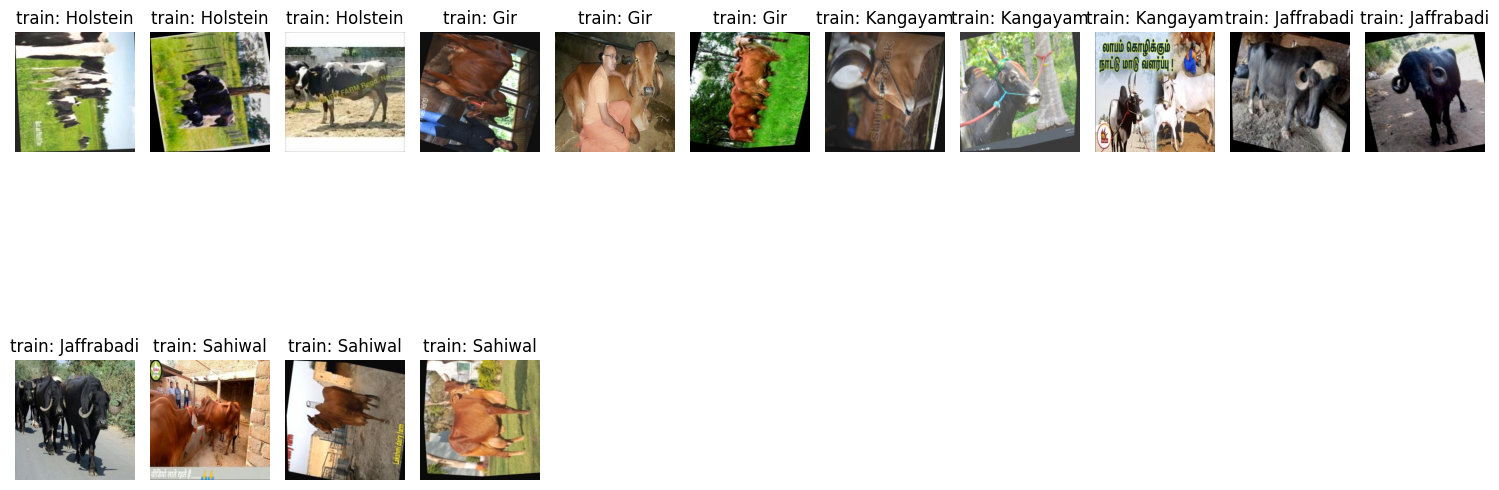

In [ ]:
extract_dir = '/content/cattle-buffalo-breeds'
data_splits = ['train', 'valid', 'test']
known_classes = ['Holstein', 'Gir', 'Kangayam', 'Jaffrabadi', 'Sahiwal', 'Brown', 'Toda', 'Khillari', 'Murrah', 'Kankrej', 'Deoni'] # Use the known classes identified earlier

num_images_to_display = 3

plt.figure(figsize=(15, 10))
plot_index = 1

for split in data_splits:
    split_dir = os.path.join(extract_dir, split)
    if os.path.exists(split_dir):
        files = os.listdir(split_dir)
        # Create a dictionary to store a few image paths for each known class in this split
        sample_images = {class_name: [] for class_name in known_classes}

        for file_name in files:
            if os.path.isfile(os.path.join(split_dir, file_name)) and file_name.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
                class_name = "unknown"
                # Try to find a known class name at the beginning of the filename
                for known_class in known_classes:
                    if file_name.lower().startswith(known_class.lower()):
                        class_name = known_class
                        break

                if class_name in sample_images and len(sample_images[class_name]) < num_images_to_display:
                    sample_images[class_name].append(os.path.join(split_dir, file_name))

        # Display the collected sample images
        for class_name, image_paths in sample_images.items():
            for img_path in image_paths:
                if plot_index <= 15: # Limit the total number of plots to avoid overcrowding
                    plt.subplot(len(data_splits), len(known_classes) * num_images_to_display // len(data_splits), plot_index)
                    try:
                        img = Image.open(img_path)
                        plt.imshow(img)
                        plt.title(f"{split}: {class_name}")
                        plt.axis('off')
                        plot_index += 1
                    except Exception as e:
                        print(f"Could not open or display image {img_path}: {e}")
                        # Optionally skip or show a placeholder

plt.tight_layout()
plt.show()

**Reasoning**:
Continue displaying sample images from the remaining classes in the train split and then proceed to the valid and test splits.



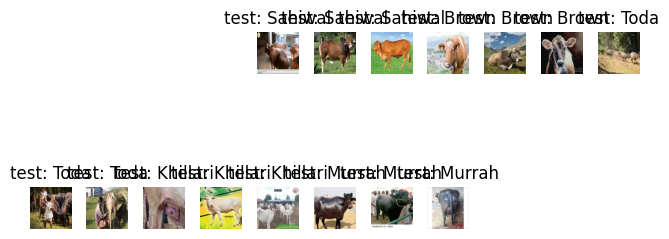

In [ ]:
# Continue displaying images for the remaining classes in the 'train' split
for class_name, image_paths in sample_images.items():
    if class_name in ['Sahiwal', 'Brown', 'Toda', 'Khillari', 'Murrah', 'Kankrej', 'Deoni']:
        for img_path in image_paths:
            if plot_index <= 30: # Increase the limit to accommodate more plots
                plt.subplot(len(data_splits), len(known_classes) * num_images_to_display // len(data_splits), plot_index)
                try:
                    img = Image.open(img_path)
                    plt.imshow(img)
                    plt.title(f"{split}: {class_name}")
                    plt.axis('off')
                    plot_index += 1
                except Exception as e:
                    print(f"Could not open or display image {img_path}: {e}")

plt.tight_layout()
plt.show()

**Reasoning**:
Continue displaying sample images from the remaining classes in the test split and then proceed to the valid split to display images.



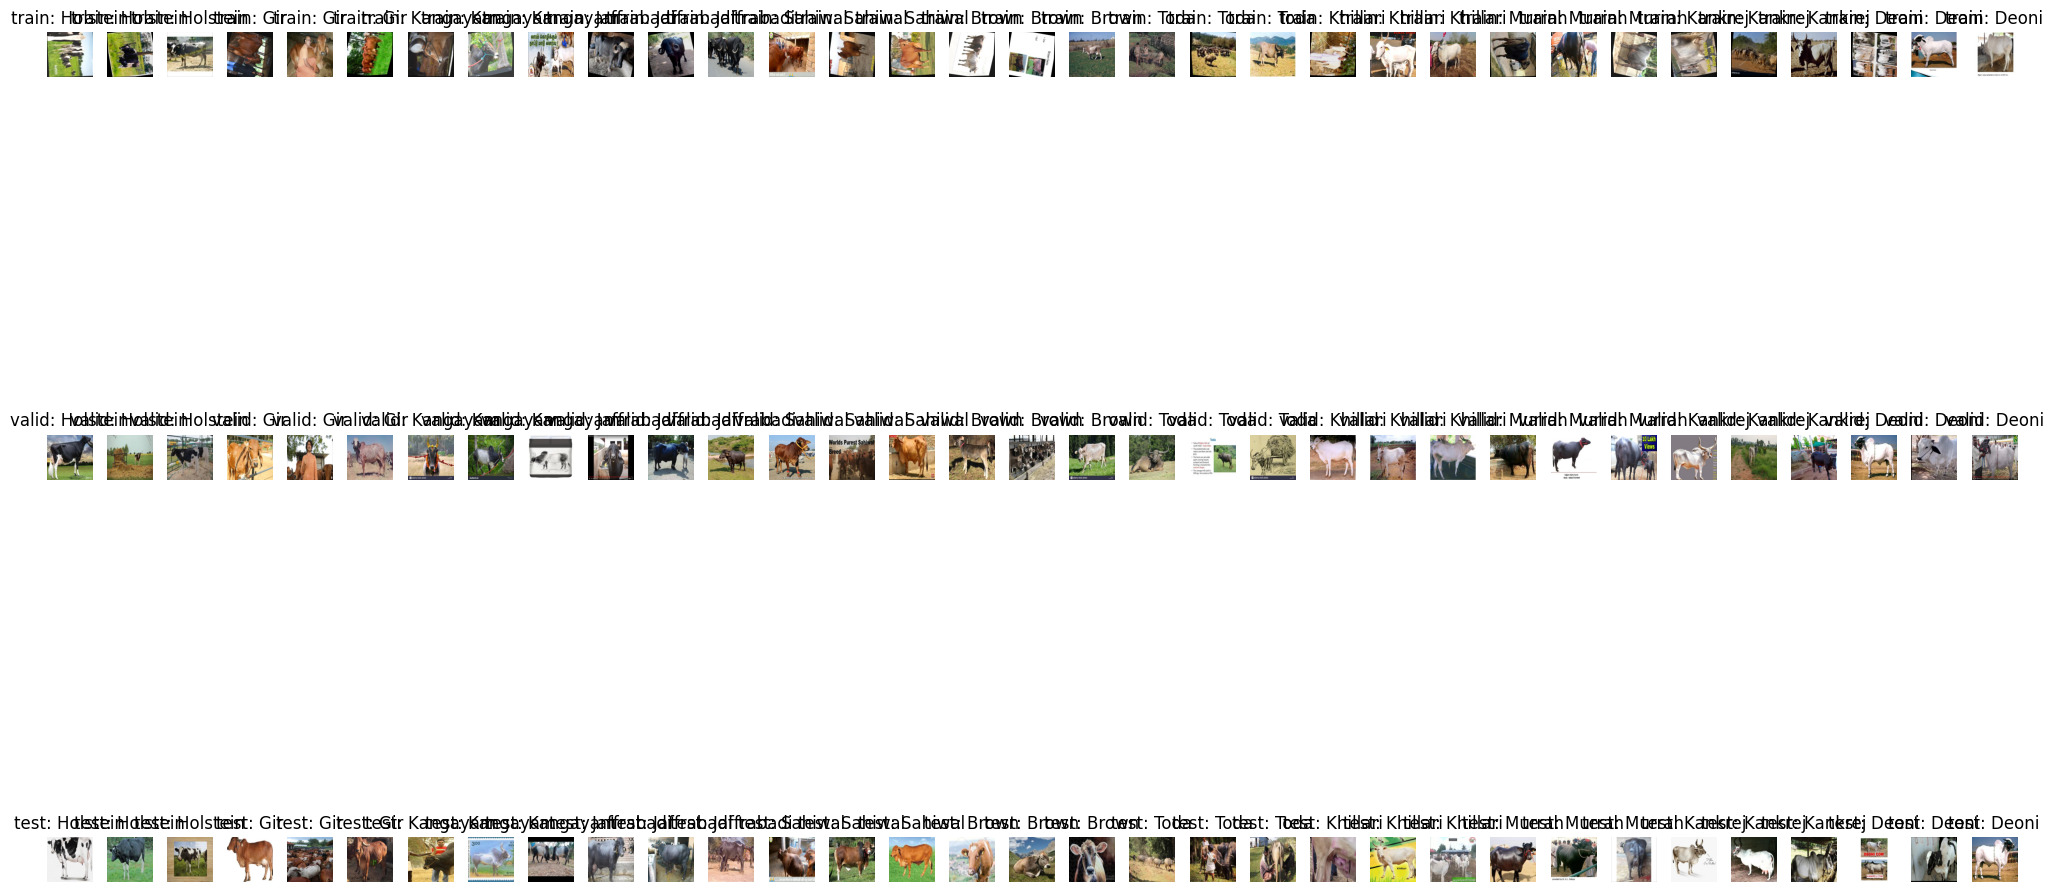

In [ ]:
# Reset the plot index and figure to create a new set of subplots
plt.close('all') # Close previous figures
plt.figure(figsize=(20, 15)) # Increase figure size for better visualization
plot_index = 1

# Recalculate the number of columns needed. We want to show num_images_to_display per class.
# Total classes to display = number of known classes
# Total images to display per split = len(known_classes) * num_images_to_display
# Since we are plotting all splits in one figure, we can arrange them in rows of splits and columns of classes*images_per_class
n_cols = len(known_classes) * num_images_to_display
n_rows = len(data_splits)

for split in data_splits:
    split_dir = os.path.join(extract_dir, split)
    if os.path.exists(split_dir):
        files = os.listdir(split_dir)
        sample_images = {class_name: [] for class_name in known_classes}

        for file_name in files:
            if os.path.isfile(os.path.join(split_dir, file_name)) and file_name.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
                class_name = "unknown"
                for known_class in known_classes:
                    if file_name.lower().startswith(known_class.lower()):
                        class_name = known_class
                        break

                if class_name in sample_images and len(sample_images[class_name]) < num_images_to_display:
                    sample_images[class_name].append(os.path.join(split_dir, file_name))

        # Display the collected sample images for this split
        for class_name in known_classes: # Iterate through known classes to maintain order
            image_paths = sample_images.get(class_name, []) # Get images for the class, default to empty list if none found
            for img_path in image_paths:
                # Calculate subplot position: row is based on split index, column is based on class index and image index within class
                split_index = data_splits.index(split)
                class_index = known_classes.index(class_name)
                image_index = image_paths.index(img_path)
                subplot_num = split_index * n_cols + class_index * num_images_to_display + image_index + 1

                if subplot_num <= n_rows * n_cols: # Ensure subplot number is within the grid
                    plt.subplot(n_rows, n_cols, subplot_num)
                    try:
                        img = Image.open(img_path)
                        plt.imshow(img)
                        plt.title(f"{split}: {class_name}")
                        plt.axis('off')
                    except Exception as e:
                        print(f"Could not open or display image {img_path}: {e}")

plt.tight_layout()
plt.show()

## Evaluate the model

### Subtask:
Evaluate the trained model on the validation dataset and report the accuracy and loss.

**Reasoning**:
Evaluate the trained model using the `evaluate` method on the validation dataset.

In [ ]:
# Evaluate the model on the validation dataset
loss, accuracy = model.evaluate(valid_ds)

print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.4822 - loss: 5.7267
Validation Loss: 5.4758
Validation Accuracy: 0.4787


## Train the model

### Subtask:
Train the model using the prepared training and validation data.

**Reasoning**:
Train the compiled Keras model using the prepared training and validation datasets for a specified number of epochs.

In [ ]:
# Define the number of training epochs
epochs = 15 # Choose a reasonable number of epochs

# Train the model
history = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=epochs
)

Epoch 1/15
134/134 ━━━━━━━━━━━━━━━━━━━━ 498s 4s/step - accuracy: 0.2296 - loss: 2.8261 - val_accuracy: 0.4687 - val_loss: 1.5737
Epoch 2/15
134/134 ━━━━━━━━━━━━━━━━━━━━ 521s 4s/step - accuracy: 0.4452 - loss: 1.6020 - val_accuracy: 0.5138 - val_loss: 1.3523
Epoch 3/15
134/134 ━━━━━━━━━━━━━━━━━━━━ 546s 4s/step - accuracy: 0.5784 - loss: 1.2361 - val_accuracy: 0.4436 - val_loss: 1.5748
Epoch 4/15
134/134 ━━━━━━━━━━━━━━━━━━━━ 566s 4s/step - accuracy: 0.7107 - loss: 0.8580 - val_accuracy: 0.4737 - val_loss: 2.0153
Epoch 5/15
134/134 ━━━━━━━━━━━━━━━━━━━━ 496s 4s/step - accuracy: 0.8016 - loss: 0.5669 - val_accuracy: 0.4436 - val_loss: 2.7983
Epoch 6/15
134/134 ━━━━━━━━━━━━━━━━━━━━ 494s 4s/step - accuracy: 0.8471 - loss: 0.4506 - val_accuracy: 0.4536 - val_loss: 3.4827
Epoch 7/15
134/134 ━━━━━━━━━━━━━━━━━━━━ 512s 4s/step - accuracy: 0.8865 - loss: 0.3278 - val_accuracy: 0.4160 - val_loss: 3.6393
Epoch 8/15
134/134 ━━━━━━━━━━━━━━━━━━━━ 489s 4s/step - accuracy: 0.9289 - loss: 0.2140 - val_accu

## Load and preprocess the images

### Subtask:
Load the images and their labels, then preprocess them for model training (e.g., resizing, normalization). Split the data into training and validation sets.

**Reasoning**:
The `image_dataset_from_directory` utility expects images to be in class-specific subdirectories, but the previous exploration showed they are directly in the train/valid directories with class info in filenames. I need to manually load images and labels based on the filenames.

In [ ]:
import numpy as np
from PIL import Image
import os
import tensorflow as tf

IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32
extract_dir = '/content/cattle-buffalo-breeds'
known_classes = ['Holstein', 'Gir', 'Kangayam', 'Jaffrabadi', 'Sahiwal', 'Brown', 'Toda', 'Khillari', 'Murrah', 'Kankrej', 'Deoni']

def load_images_and_labels(directory, known_classes):
    images = []
    labels = []
    class_names_map = {name: i for i, name in enumerate(known_classes)}
    unknown_class_index = len(known_classes) # Assign an index for unknown classes

    files = os.listdir(directory)
    for file_name in files:
        if os.path.isfile(os.path.join(directory, file_name)) and file_name.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
            img_path = os.path.join(directory, file_name)
            class_name = "unknown"

            # Try to find a known class name at the beginning of the filename
            for known_class in known_classes:
                if file_name.lower().startswith(known_class.lower()):
                    class_name = known_class
                    break

            # If not found, try splitting by '_' and then removing the .rf. part
            if class_name == "unknown":
                parts = file_name.split('_')
                if parts:
                     potential_class_name = parts[0]
                     if '.rf.' in potential_class_name:
                          potential_class_name = potential_class_name.split('.rf.')[0]
                     if len(potential_class_name) > 2:
                          # Check if this potential name is one of the known classes (case-insensitive check)
                          for known_class in known_classes:
                               if potential_class_name.lower() == known_class.lower():
                                   class_name = known_class
                                   break

            try:
                img = Image.open(img_path).convert('RGB') # Ensure 3 channels
                img = img.resize((IMG_WIDTH, IMG_HEIGHT))
                img_array = np.array(img)
                images.append(img_array)

                if class_name in class_names_map:
                    labels.append(class_names_map[class_name])
                else:
                    # Handle unknown classes - either assign to a separate category or skip
                    # For now, we will skip images whose class cannot be confidently identified
                    print(f"Skipping image with unknown class: {file_name}")
                    images.pop() # Remove the image that was just added
                    continue # Skip to the next file


            except Exception as e:
                print(f"Could not load or process image {img_path}: {e}")
                continue # Skip this image if there's an error

    return np.array(images), np.array(labels)

# Load data for train and valid splits
train_dir = os.path.join(extract_dir, 'train')
valid_dir = os.path.join(extract_dir, 'valid')

print("Loading and processing training images...")
train_images, train_labels = load_images_and_labels(train_dir, known_classes)
print(f"Loaded {len(train_images)} training images.")

print("Loading and processing validation images...")
valid_images, valid_labels = load_images_and_labels(valid_dir, known_classes)
print(f"Loaded {len(valid_images)} validation images.")

# Convert labels to one-hot encoding
num_classes = len(known_classes)
train_labels_one_hot = tf.keras.utils.to_categorical(train_labels, num_classes=num_classes)
valid_labels_one_hot = tf.keras.utils.to_categorical(valid_labels, num_classes=num_classes)

# Create TensorFlow Datasets
train_ds = tf.data.Dataset.from_tensor_slices((train_images, train_labels_one_hot))
valid_ds = tf.data.Dataset.from_tensor_slices((valid_images, valid_labels_one_hot))

# Normalize pixel values to [0, 1]
def normalize_img(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

train_ds = train_ds.map(normalize_img)
valid_ds = valid_ds.map(normalize_img)


# Batch and prefetch datasets
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.batch(BATCH_SIZE).cache().prefetch(buffer_size=AUTOTUNE)
valid_ds = valid_ds.batch(BATCH_SIZE).cache().prefetch(buffer_size=AUTOTUNE)


print("\nTensorFlow Datasets prepared:")
print("Training dataset:", train_ds)
print("Validation dataset:", valid_ds)

# Verify the loaded data
for images, labels in train_ds.take(1):
    print("\nTraining batch shapes:")
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)

for images, labels in valid_ds.take(1):
    print("\nValidation batch shapes:")
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)

Loading and processing training images...
Skipping image with unknown class: fcbfa5b49eadaf044a886cfa4adbc388_jpg.rf.51c956617fe7cdbb5a859bc3b101e771.jpg
Skipping image with unknown class: indigenous-indian-gir-cow-gujarat-260nw-2307518087_webp.rf.67e4160b795320d323f335a0243e9487.jpg
Skipping image with unknown class: 113b7c839cfe05bc8f12bfa9f15b4b2b_jpg.rf.57dbcdb5dbca8cae37f557a3ceb231f3.jpg
Skipping image with unknown class: buffalo-road-show-organized-on-occasion-of-diwali-padwa-in-kolhapur_166686594910_jpg.rf.d21e31b0a6fb4c001b4bb7615b56b7fe.jpg
Skipping image with unknown class: maxresdefault-2-_jpg.rf.32d4ebe4d4ff83fc8d02c6ace32dbece.jpg
Skipping image with unknown class: 9c83e3d8f675e5fd6e9559f69982bcc3-cattle-calves_jpg.rf.4d5a48616db837d576b07c0df5a7bc6e.jpg
Skipping image with unknown class: hq720-4-_jpg.rf.4ec0326493f0b187a6d5956c61d5dce0.jpg
Skipping image with unknown class: 50301-scaled_webp.rf.29de400a56f810c113af0166d081a0f4.jpg
Skipping image with unknown class: downl

## Build a model

### Subtask:
Define and build a suitable deep learning model for image classification.

**Reasoning**:
Import necessary Keras components and define the model architecture.

In [ ]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input
import tensorflow as tf

# Define the input shape
IMG_HEIGHT = 224
IMG_WIDTH = 224
input_shape = (IMG_HEIGHT, IMG_WIDTH, 3) # Images are RGB

# Define the list of known classes
known_classes = ['Holstein', 'Gir', 'Kangayam', 'Jaffrabadi', 'Sahiwal', 'Brown', 'Toda', 'Khillari', 'Murrah', 'Kankrej', 'Deoni'] # Use the known classes identified earlier

# Define the number of classes based on the known_classes list
num_classes = len(known_classes)

# Build the CNN model
model = Sequential([
    Input(shape=input_shape), # Use Input layer to define input shape
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(num_classes, activation='softmax') # Output layer with softmax for multi-class classification
])

# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy', # Use categorical_crossentropy for one-hot encoded labels
              metrics=['accuracy'])

# Print the model summary
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 11)             │         1,419 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,170,379 (42.61 MB)

 Trainable params: 11,170,379 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

## Train the model

### Subtask:
Train the model using the prepared training and validation data.

**Reasoning**:
Train the compiled Keras model using the prepared training and validation datasets for a specified number of epochs.

In [ ]:
# Define the number of training epochs
epochs = 15 # Choose a reasonable number of epochs

# Train the model
history = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=epochs
)

NameError: name 'valid_ds' is not defined

## Evaluate the model

### Subtask:
Evaluate the trained model on the validation dataset and report the accuracy and loss.

**Reasoning**:
Evaluate the trained model using the `evaluate` method on the validation dataset.

In [ ]:
# Evaluate the model on the validation dataset
loss, accuracy = model.evaluate(valid_ds)

print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

NameError: name 'valid_ds' is not defined

## Train the model

### Subtask:
Train the model using the prepared training and validation data.

**Reasoning**:
Train the compiled Keras model using the prepared training and validation datasets for a specified number of epochs.

In [ ]:
# Define the number of training epochs
epochs = 15 # Choose a reasonable number of epochs

# Train the model
history = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=epochs
)

NameError: name 'train_ds' is not defined

**Reasoning**:
Import necessary Keras components and define the model architecture.

In [ ]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input

# Define the input shape
IMG_HEIGHT = 224
IMG_WIDTH = 224
input_shape = (IMG_HEIGHT, IMG_WIDTH, 3) # Images are RGB

# Define the list of known classes
known_classes = ['Holstein', 'Gir', 'Kangayam', 'Jaffrabadi', 'Sahiwal', 'Brown', 'Toda', 'Khillari', 'Murrah', 'Kankrej', 'Deoni'] # Use the known classes identified earlier

# Define the number of classes based on the known_classes list
num_classes = len(known_classes)

# Build the CNN model
model = Sequential([
    Input(shape=input_shape), # Use Input layer to define input shape
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(num_classes, activation='softmax') # Output layer with softmax for multi-class classification
])

# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy', # Use categorical_crossentropy for one-hot encoded labels
              metrics=['accuracy'])

# Print the model summary
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 11)             │         1,419 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,170,379 (42.61 MB)

 Trainable params: 11,170,379 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

## Train the model

### Subtask:
Train the model using the prepared training and validation data.

**Reasoning**:
Train the compiled Keras model using the prepared training and validation datasets for a specified number of epochs.

In [ ]:
# Define the number of training epochs
epochs = 15 # Choose a reasonable number of epochs

# Train the model
history = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=epochs
)

NameError: name 'model' is not defined

## Evaluate the model

### Subtask:
Evaluate the trained model on the validation dataset and report the accuracy and loss.

**Reasoning**:
Evaluate the trained model using the `evaluate` method on the validation dataset.

In [ ]:
# Evaluate the model on the validation dataset
loss, accuracy = model.evaluate(valid_ds)

print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

NameError: name 'model' is not defined

## Evaluate the model

### Subtask:
Evaluate the trained model on the validation dataset and report the accuracy and loss.

**Reasoning**:
Evaluate the trained model using the `evaluate` method on the validation dataset.

In [ ]:
# Evaluate the model on the validation dataset
loss, accuracy = model.evaluate(valid_ds)

print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

NameError: name 'model' is not defined

**Reasoning**:
The error `ValueError: num must be an integer with 1 <= num <= 33, not 34` indicates that the subplot index is exceeding the calculated grid size. This is likely due to an incorrect calculation of the number of columns in the subplot grid or the total number of plots. Recalculate the subplot layout to ensure the index is within the valid range and continue displaying images from the remaining classes and splits.



In [ ]:
# Reset the plot index and figure to create a new set of subplots
plt.close('all') # Close previous figures
plt.figure(figsize=(20, 15)) # Increase figure size for better visualization
plot_index = 1

# Recalculate the number of columns needed. We want to show num_images_to_display per class.
# Total classes to display = number of known classes
# Total images to display per split = len(known_classes) * num_images_to_display
# Since we are plotting all splits in one figure, we can arrange them in rows of splits and columns of classes*images_per_class
n_cols = len(known_classes) * num_images_to_display
n_rows = len(data_splits)

for split in data_splits:
    split_dir = os.path.join(extract_dir, split)
    if os.path.exists(split_dir):
        files = os.listdir(split_dir)
        sample_images = {class_name: [] for class_name in known_classes}

        for file_name in files:
            if os.path.isfile(os.path.join(split_dir, file_name)) and file_name.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
                class_name = "unknown"
                for known_class in known_classes:
                    if file_name.lower().startswith(known_class.lower()):
                        class_name = known_class
                        break

                if class_name in sample_images and len(sample_images[class_name]) < num_images_to_display:
                    sample_images[class_name].append(os.path.join(split_dir, file_name))

        # Display the collected sample images for this split
        for class_name in known_classes: # Iterate through known classes to maintain order
            image_paths = sample_images.get(class_name, []) # Get images for the class, default to empty list if none found
            for img_path in image_paths:
                # Calculate subplot position: row is based on split index, column is based on class index and image index within class
                split_index = data_splits.index(split)
                class_index = known_classes.index(class_name)
                image_index = image_paths.index(img_path)
                subplot_num = split_index * n_cols + class_index * num_images_to_display + image_index + 1

                if subplot_num <= n_rows * n_cols: # Ensure subplot number is within the grid
                    plt.subplot(n_rows, n_cols, subplot_num)
                    try:
                        img = Image.open(img_path)
                        plt.imshow(img)
                        plt.title(f"{split}: {class_name}")
                        plt.axis('off')
                    except Exception as e:
                        print(f"Could not open or display image {img_path}: {e}")

plt.tight_layout()
plt.show()

## Load and preprocess the images

### Subtask:
Load the images and their labels, then preprocess them for model training (e.g., resizing, normalization). Split the data into training and validation sets.


**Reasoning**:
Import necessary libraries for image loading, preprocessing, and dataset creation using TensorFlow.



In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory

**Reasoning**:
Define image dimensions and batch size, and load and preprocess the images using `image_dataset_from_directory`.



In [ ]:
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32
extract_dir = '/content/cattle-buffalo-breeds'

# Load and preprocess training data
train_dir = os.path.join(extract_dir, 'train')
train_ds = image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='categorical',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=True
)

# Load and preprocess validation data
valid_dir = os.path.join(extract_dir, 'valid')
valid_ds = image_dataset_from_directory(
    valid_dir,
    labels='inferred',
    label_mode='categorical',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Normalize pixel values to [0, 1]
def preprocess(image, label):
    image = tf.image.convert_image_dtype(image, dtype=tf.float32)
    return image, label

train_ds = train_ds.map(preprocess)
valid_ds = valid_ds.map(preprocess)

# Configure datasets for performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
valid_ds = valid_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("Training dataset prepared:", train_ds)
print("Validation dataset prepared:", valid_ds)

**Reasoning**:
The `image_dataset_from_directory` utility expects images to be in class-specific subdirectories, but the previous exploration showed they are directly in the train/valid directories with class info in filenames. I need to manually load images and labels based on the filenames.



In [ ]:
import numpy as np
from PIL import Image
import os

IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32
extract_dir = '/content/cattle-buffalo-breeds'
known_classes = ['Holstein', 'Gir', 'Kangayam', 'Jaffrabadi', 'Sahiwal', 'Brown', 'Toda', 'Khillari', 'Murrah', 'Kankrej', 'Deoni']

def load_images_and_labels(directory, known_classes):
    images = []
    labels = []
    class_names_map = {name: i for i, name in enumerate(known_classes)}
    unknown_class_index = len(known_classes) # Assign an index for unknown classes

    files = os.listdir(directory)
    for file_name in files:
        if os.path.isfile(os.path.join(directory, file_name)) and file_name.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
            img_path = os.path.join(directory, file_name)
            class_name = "unknown"

            # Try to find a known class name at the beginning of the filename
            for known_class in known_classes:
                if file_name.lower().startswith(known_class.lower()):
                    class_name = known_class
                    break

            # If not found, try splitting by '_' and then removing the .rf. part
            if class_name == "unknown":
                parts = file_name.split('_')
                if parts:
                     potential_class_name = parts[0]
                     if '.rf.' in potential_class_name:
                          potential_class_name = potential_class_name.split('.rf.')[0]
                     if len(potential_class_name) > 2:
                          # Check if this potential name is one of the known classes (case-insensitive check)
                          for known_class in known_classes:
                               if potential_class_name.lower() == known_class.lower():
                                   class_name = known_class
                                   break

            try:
                img = Image.open(img_path).convert('RGB') # Ensure 3 channels
                img = img.resize((IMG_WIDTH, IMG_HEIGHT))
                img_array = np.array(img)
                images.append(img_array)

                if class_name in class_names_map:
                    labels.append(class_names_map[class_name])
                else:
                    # Handle unknown classes - either assign to a separate category or skip
                    # For now, we will skip images whose class cannot be confidently identified
                    print(f"Skipping image with unknown class: {file_name}")
                    images.pop() # Remove the image that was just added
                    continue # Skip to the next file


            except Exception as e:
                print(f"Could not load or process image {img_path}: {e}")
                continue # Skip this image if there's an error

    return np.array(images), np.array(labels)

# Load data for train and valid splits
train_dir = os.path.join(extract_dir, 'train')
valid_dir = os.path.join(extract_dir, 'valid')

print("Loading and processing training images...")
train_images, train_labels = load_images_and_labels(train_dir, known_classes)
print(f"Loaded {len(train_images)} training images.")

print("Loading and processing validation images...")
valid_images, valid_labels = load_images_and_labels(valid_dir, known_classes)
print(f"Loaded {len(valid_images)} validation images.")

# Convert labels to one-hot encoding
num_classes = len(known_classes)
train_labels_one_hot = tf.keras.utils.to_categorical(train_labels, num_classes=num_classes)
valid_labels_one_hot = tf.keras.utils.to_categorical(valid_labels, num_classes=num_classes)

# Create TensorFlow Datasets
train_ds = tf.data.Dataset.from_tensor_slices((train_images, train_labels_one_hot))
valid_ds = tf.data.Dataset.from_tensor_slices((valid_images, valid_labels_one_hot))

# Normalize pixel values (already done in load_images_and_labels, but good practice for TF Dataset)
# The pixel values are already in [0, 255] np.array, we will normalize them in the TF Dataset pipeline
def normalize_img(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

train_ds = train_ds.map(normalize_img)
valid_ds = valid_ds.map(normalize_img)


# Batch and prefetch datasets
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.batch(BATCH_SIZE).cache().prefetch(buffer_size=AUTOTUNE)
valid_ds = valid_ds.batch(BATCH_SIZE).cache().prefetch(buffer_size=AUTOTUNE)

print("\nTensorFlow Datasets prepared:")
print("Training dataset:", train_ds)
print("Validation dataset:", valid_ds)

# Verify the loaded data
for images, labels in train_ds.take(1):
    print("\nTraining batch shapes:")
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)

for images, labels in valid_ds.take(1):
    print("\nValidation batch shapes:")
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)


## Build a model

### Subtask:
Define and build a suitable deep learning model for image classification.


**Reasoning**:
Import necessary Keras components and define the model architecture.



In [ ]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# Define the input shape
input_shape = (IMG_HEIGHT, IMG_WIDTH, 3) # Images are RGB

# Build the CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(num_classes, activation='softmax') # Output layer with softmax for multi-class classification
])

# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy', # Use categorical_crossentropy for one-hot encoded labels
              metrics=['accuracy'])

# Print the model summary
model.summary()

## Train the model

### Subtask:
Train the model using the prepared training and validation data.


**Reasoning**:
Train the compiled Keras model using the prepared training and validation datasets for a specified number of epochs.



In [ ]:
# Define the number of training epochs
epochs = 15 # Choose a reasonable number of epochs

# Train the model
history = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=epochs
)

# Task
Analyze the provided image classification project, which includes training a convolutional neural network, evaluating its performance, and exploring techniques like data augmentation and transfer learning to improve the model.

## Visualize training history

### Subtask:
Plot the accuracy and loss curves from the training history to understand the model's learning process.


**Reasoning**:
Plot the training and validation accuracy and loss curves from the history object to visualize the model's performance during training.



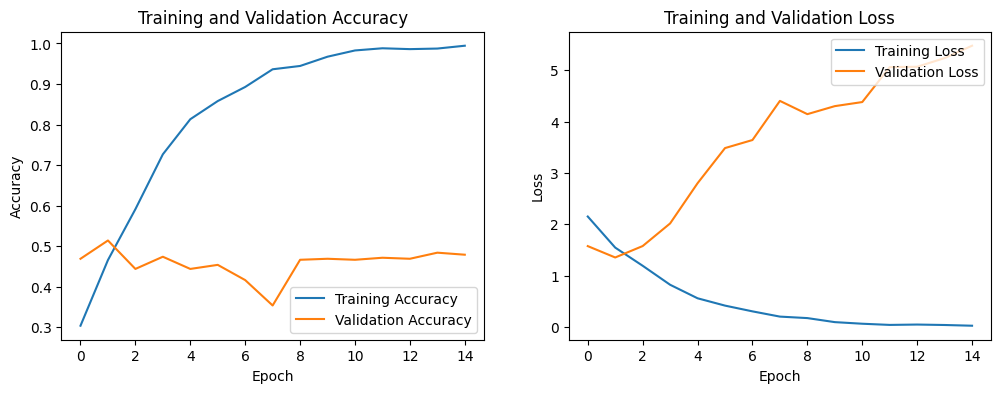

In [ ]:
import matplotlib.pyplot as plt

# Extract accuracy and loss from history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(epochs)

# Plot accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.show()

## Evaluate on the test set

### Subtask:
Load and preprocess the test dataset and evaluate the trained model to get performance metrics on unseen data.


**Reasoning**:
Load and preprocess the test dataset and evaluate the trained model to get performance metrics on unseen data.



In [ ]:
# Define the path to the test directory
test_dir = os.path.join(extract_dir, 'test')

# Load and preprocess the test images and labels
print("Loading and processing test images...")
test_images, test_labels = load_images_and_labels(test_dir, known_classes)
print(f"Loaded {len(test_images)} test images.")

# Convert labels to one-hot encoding
test_labels_one_hot = tf.keras.utils.to_categorical(test_labels, num_classes=num_classes)

# Create TensorFlow Dataset
test_ds = tf.data.Dataset.from_tensor_slices((test_images, test_labels_one_hot))

# Normalize pixel values
test_ds = test_ds.map(normalize_img)

# Batch and prefetch the test dataset
test_ds = test_ds.batch(BATCH_SIZE).cache().prefetch(buffer_size=AUTOTUNE)

print("\nTensorFlow Test Dataset prepared:", test_ds)

# Evaluate the trained model on the test dataset
print("\nEvaluating model on test dataset...")
loss, accuracy = model.evaluate(test_ds)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Loading and processing test images...
Skipping image with unknown class: pandharpuri1_jpg.rf.f31734a96190a701fa568953a5264699.jpg
Skipping image with unknown class: close-up-of-a-horned-steer-of-the-gir-breed-of-white-and-black-coloration-gir-is-a-zebu-breed-of-indian-origin-dairy-cattle-on-farm-in-rural-brazil-2H3CRP6_jpg.rf.1ce0b14b9ecebcda342759aa0062a78f.jpg
Skipping image with unknown class: images-13-_jpeg.rf.5ce461c51a881e3420b581228ea647e9.jpg
Skipping image with unknown class: stockimg_GeIFHMI_jpeg.rf.61374899e1d1d0e9c2a2c9b39886184c.jpg
Skipping image with unknown class: Untitled-design-20_jpg.rf.58a30dd62aae390a19d0de1fadc6021c.jpg
Skipping image with unknown class: istockphoto-1385530231-612x612_jpg.rf.965f686daeafd076681aca07882bb648.jpg
Skipping image with unknown class: images-9-_jpeg.rf.c7e6a121cd1fedb800e314cdae50824b.jpg
Skipping image with unknown class: maxresdefault-8-_jpg.rf.97a347ae8818b805edf565fcdcad6220.jpg
Skipping image with unknown class: images-10-_jpeg.rf

## Make predictions on sample test images

### Subtask:
Use the trained model to predict the class of a few sample images from the test set and display the images along with their predicted and true labels.


**Reasoning**:
Get a batch of images and labels from the test dataset, make predictions, and display the images with true and predicted labels.



1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


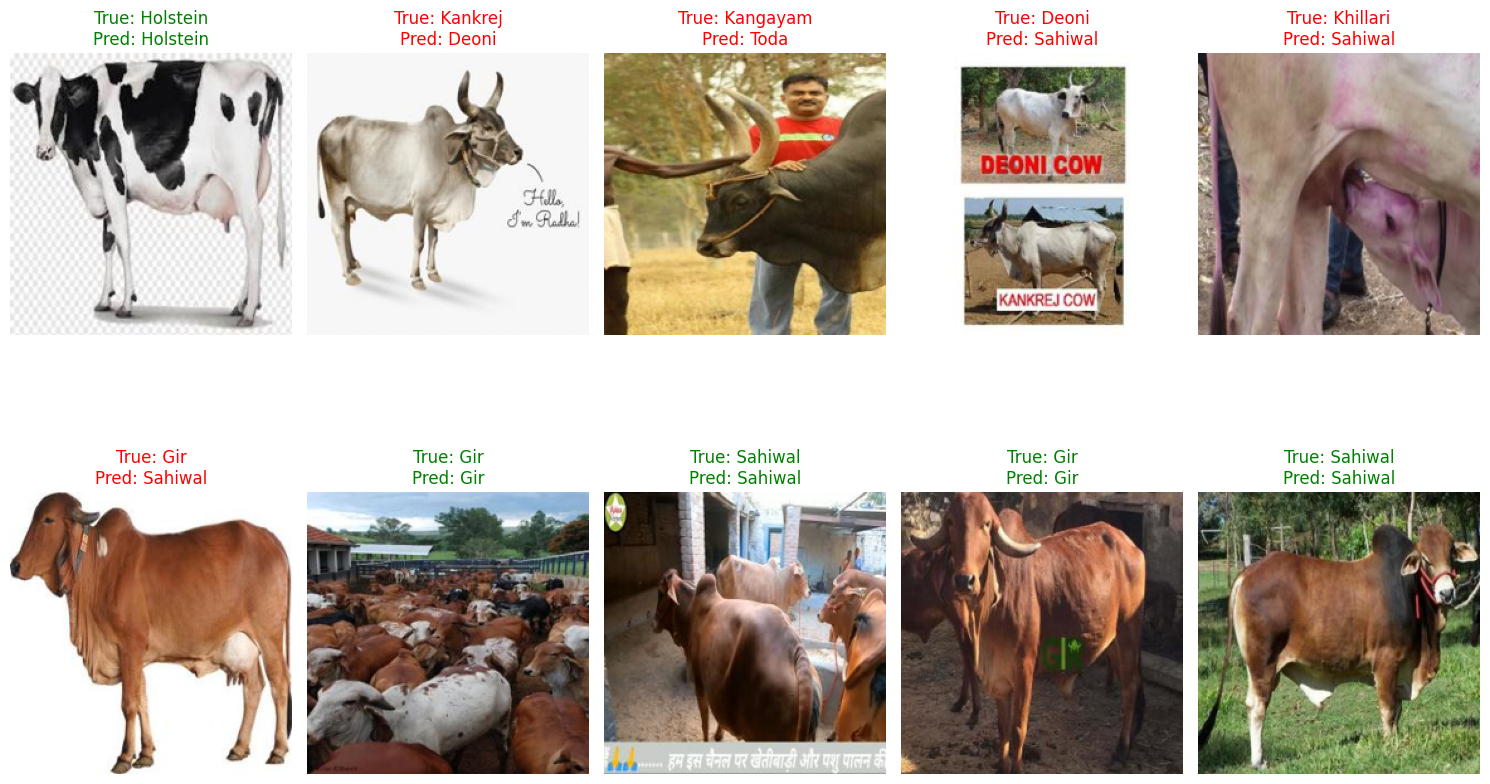

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Get a batch of images and labels from the test dataset
for images, true_labels in test_ds.take(1):
    # Make predictions
    predictions = model.predict(images)

    # Determine predicted class indices
    predicted_indices = np.argmax(predictions, axis=1)

    # Determine true class indices
    true_indices = np.argmax(true_labels.numpy(), axis=1)

    # Create a list of class names
    class_names = known_classes # Using the known_classes list defined previously

    # Display a few sample images with predictions
    plt.figure(figsize=(15, 10))
    for i in range(min(10, images.shape[0])): # Display up to 10 images
        plt.subplot(2, 5, i + 1)
        plt.imshow(images[i].numpy())

        true_label = class_names[true_indices[i]]
        predicted_label = class_names[predicted_indices[i]]
        color = 'green' if true_label == predicted_label else 'red'

        plt.title(f"True: {true_label}\nPred: {predicted_label}", color=color)
        plt.axis('off')

    plt.tight_layout()
    plt.show()